In [1]:
# Importing Libaries ToolKit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ACER\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Exploring a Data Analysis

In [2]:
# Importing & Inspecting Data
data = pd.read_csv('layoffs after clean.csv')

In [3]:
data.shape

(9955, 9)

In [4]:
data.head(10)

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Included Health,SF Bay Area,Healthcare,0,0.06,2022-07-25,Series E,United States,272
1,&Open,Dublin,Marketing,9,0.09,2022-11-17,Series A,Ireland,35
2,#Paid,Toronto,Marketing,19,0.17,2023-01-27,Series B,Canada,21
3,100 Thieves,Los Angeles,Consumer,12,NaN,2022-07-13,Series C,United States,120
4,10X Genomics,SF Bay Area,Healthcare,100,0.08,2022-08-04,Post-IPO,United States,242
5,1stdibs,New York City,Retail,70,0.17,2020-04-02,Series D,United States,253
6,2TM,Sao Paulo,Crypto,90,0.12,2022-06-01,Unknown,Brazil,250
7,2TM,Sao Paulo,Crypto,100,0.15,2022-09-01,Unknown,Brazil,250
8,2U,Washington D.C.,Education,0,0.20,2022-07-28,Post-IPO,United States,426
9,54gene,Washington D.C.,Healthcare,95,0.30,2022-08-29,Series B,United States,44


In [5]:
data.columns

Index(['company', 'location', 'industry', 'total_laid_off',
       'percentage_laid_off', 'date', 'stage', 'country',
       'funds_raised_millions'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9955 entries, 0 to 9954
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                9955 non-null   object 
 1   location               9955 non-null   object 
 2   industry               9950 non-null   object 
 3   total_laid_off         9955 non-null   int64  
 4   percentage_laid_off    7850 non-null   float64
 5   date                   9950 non-null   object 
 6   stage                  9930 non-null   object 
 7   country                9955 non-null   object 
 8   funds_raised_millions  9955 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 700.1+ KB


In [7]:
# Handle Missing Values
print(data.isna().sum())

company                     0
location                    0
industry                    5
total_laid_off              0
percentage_laid_off      2105
date                        5
stage                      25
country                     0
funds_raised_millions       0
dtype: int64


In [8]:
# Dropped rows with missing values in stage as they represented a very small proportion (<0.3%)
# of the dataset and could not be reliably imputed.
data = data.dropna(subset=['stage'])
data = data.dropna(subset=['date'])
data = data.dropna(subset=['industry'])


In [9]:
# Handle Missing Values
print(data.isna().sum())

company                     0
location                    0
industry                    0
total_laid_off              0
percentage_laid_off      2105
date                        0
stage                       0
country                     0
funds_raised_millions       0
dtype: int64


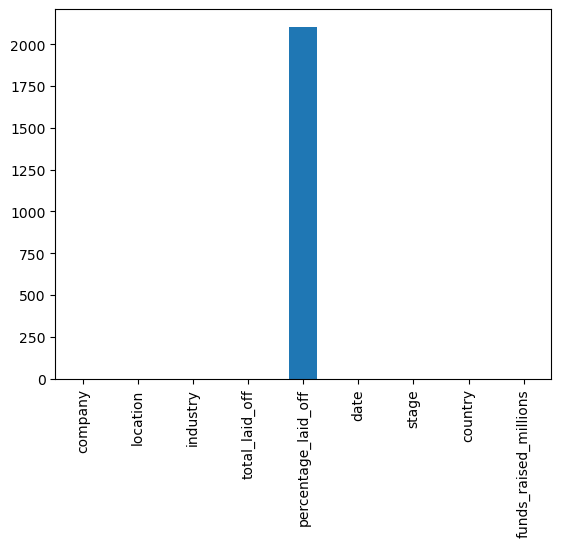

In [10]:
#Plotting missing values
data.isna().sum().plot(kind="bar")
plt.show()

In [11]:
# check duplicated values
data.duplicated().sum()

7934

In [12]:
data[data.duplicated(keep=False)]

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Included Health,SF Bay Area,Healthcare,0,0.06,2022-07-25,Series E,United States,272
1,&Open,Dublin,Marketing,9,0.09,2022-11-17,Series A,Ireland,35
2,#Paid,Toronto,Marketing,19,0.17,2023-01-27,Series B,Canada,21
3,100 Thieves,Los Angeles,Consumer,12,NaN,2022-07-13,Series C,United States,120
4,10X Genomics,SF Bay Area,Healthcare,100,0.08,2022-08-04,Post-IPO,United States,242
...,...,...,...,...,...,...,...,...,...
9950,Zuora,SF Bay Area,Finance,0,0.11,2022-12-06,Post-IPO,United States,647
9951,Zwift,Los Angeles,Fitness,150,NaN,2022-05-12,Series C,United States,619
9952,Zymergen,SF Bay Area,Other,80,NaN,2022-07-25,Acquired,United States,974
9953,Zymergen,SF Bay Area,Other,120,NaN,2021-09-23,Post-IPO,United States,974


Partial duplicates were identified based on key fields such as company and date.
Since these records were not fully identical and contained complementary information,
they were not removed. Instead, they were considered for consolidation to preserve data integrity.



In [13]:
# find the outlier and handle 
data.describe()

,total_laid_off,percentage_laid_off,funds_raised_millions
count,9920.000000,7815.000000,9920.000000
mean,192.791331,0.257810,801.570565
std,700.901936,0.255698,5788.137596
min,0.000000,0.000000,0.000000
25%,18.000000,0.100000,33.000000
50%,55.000000,0.170000,134.000000
75%,138.500000,0.300000,406.750000
max,12000.000000,1.000000,121900.000000


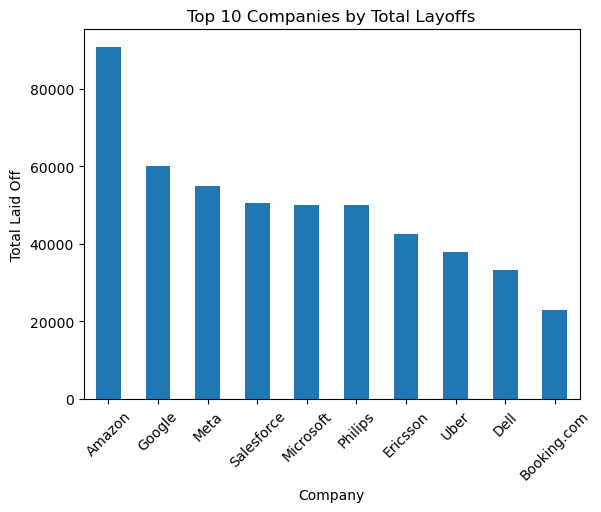

In [14]:
# Insight: Identify major companies driving layoffs
# Question: Which companies have the highest layoffs?

top_companies = data.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(10)
top_companies.plot(kind='bar')
plt.title("Top 10 Companies by Total Layoffs")
plt.xlabel("Company")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

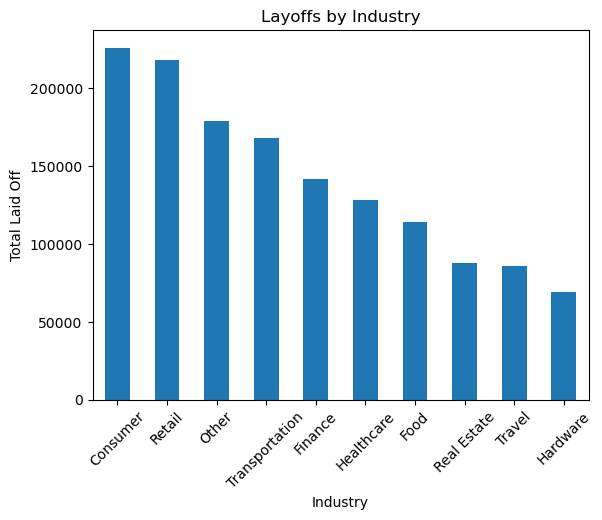

In [15]:
# Insight: Understand which sectors are unstable
# 2. Question: Which industries are most affected?

industry = data.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False).head(10)
industry.plot(kind='bar')
plt.title("Layoffs by Industry")
plt.xlabel("Industry")
plt.ylabel("Total Laid Off")
plt.xticks(rotation=45)
plt.show()

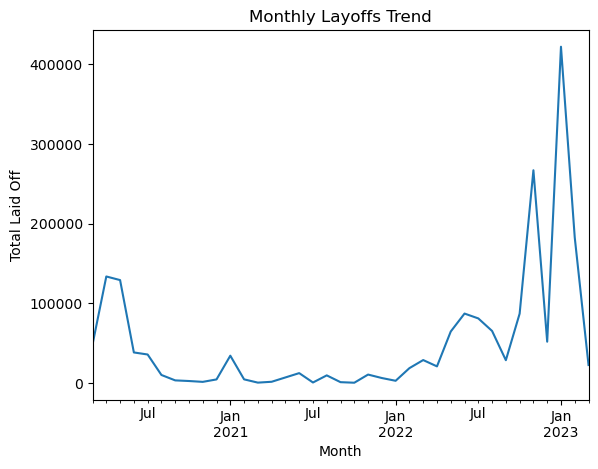

In [16]:
# Insight: Detect peaks and crisis periods
# 4. Question: How do layoffs change over time?

data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.to_period('M')
monthly = data.groupby('month')['total_laid_off'].sum()

monthly.plot()
plt.title("Monthly Layoffs Trend")
plt.xlabel("Month")
plt.ylabel("Total Laid Off")
plt.show()

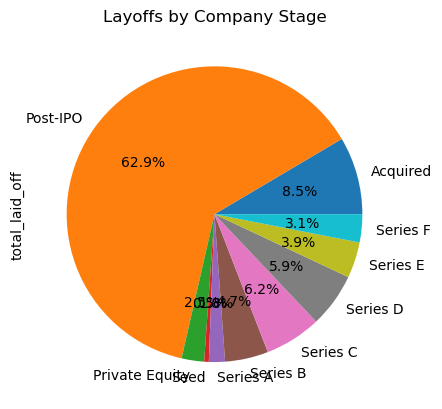

In [17]:
# 5. Question: Which company stages are most affected?
# 5. Question: Which company stages are most affected?
stage = data.groupby('stage')['total_laid_off'].sum().head(10)

stage.plot(kind='pie', autopct='%1.1f%%')
plt.title("Layoffs by Company Stage")
plt.show()

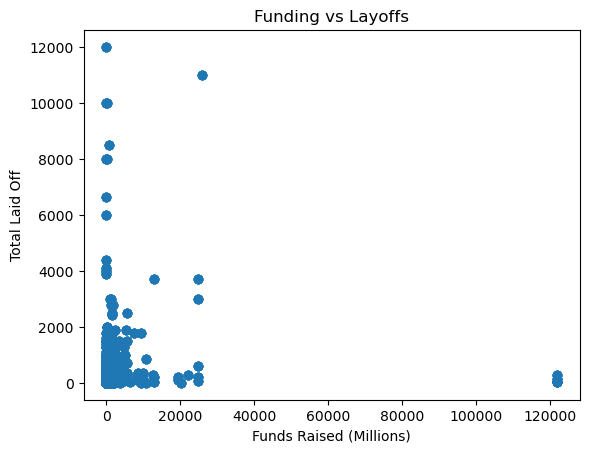

In [18]:
# Insight: Check if funding protects companies
# 6. Question: Is there a relationship between funding and layoffs?

plt.scatter(data['funds_raised_millions'], data['total_laid_off'])
plt.title("Funding vs Layoffs")
plt.xlabel("Funds Raised (Millions)")
plt.ylabel("Total Laid Off")
plt.show()

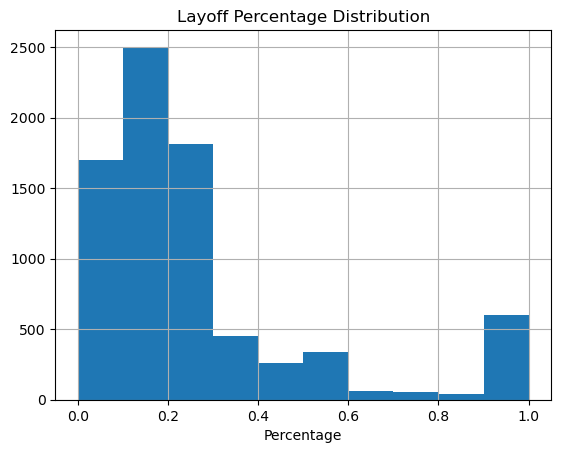

In [19]:
# Insight: Check if funding protects companies
# 7. Question: How severe are layoffs (percentage)?

data['percentage_laid_off'] = pd.to_numeric(data['percentage_laid_off'], errors='coerce')

data['percentage_laid_off'].dropna().hist()
plt.title("Layoff Percentage Distribution")
plt.xlabel("Percentage")
plt.show()



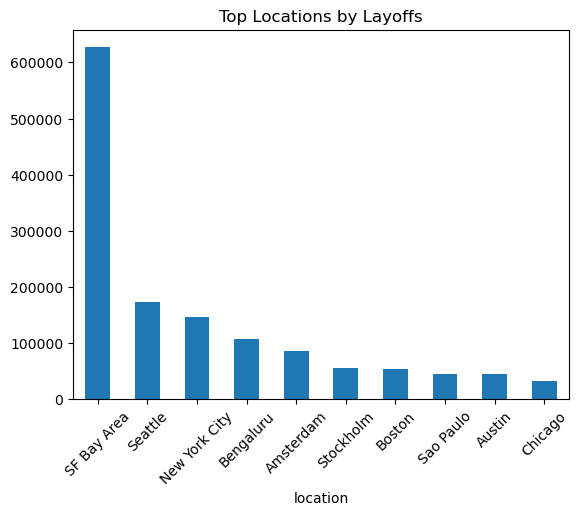

In [20]:
# Insight: Identify major affected cities
# 8. Question: Which locations (cities) are most affected?

location = data.groupby('location')['total_laid_off'].sum().sort_values(ascending=False).head(10)

location.plot(kind='bar')
plt.title("Top Locations by Layoffs")
plt.xticks(rotation=45)
plt.show()


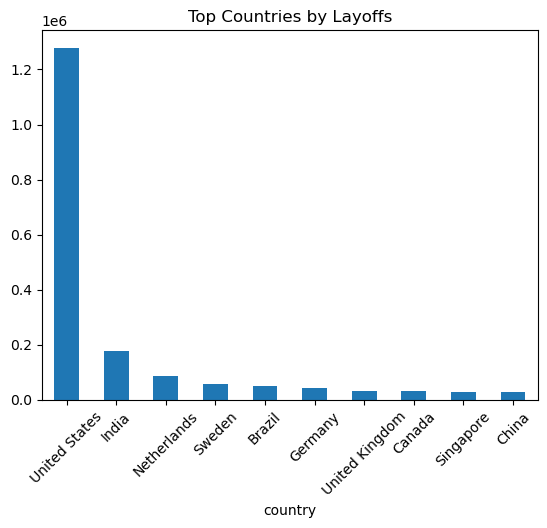

In [21]:
# 3. Layoffs by Country
country = data.groupby('country')['total_laid_off'].sum().sort_values(ascending=False).head(10)

plt.figure()
country.plot(kind='bar')
plt.title("Top Countries by Layoffs")
plt.xticks(rotation=45)
plt.show()


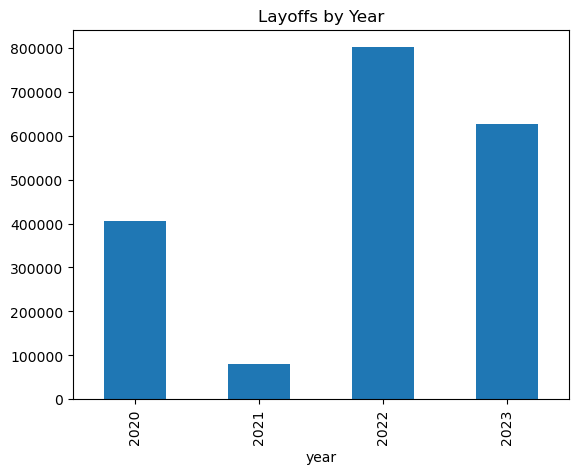

In [22]:
# 9. Yearly Trend

data['year'] = data['date'].dt.year

yearly = data.groupby('year')['total_laid_off'].sum()

plt.figure()
yearly.plot(kind='bar')
plt.title("Layoffs by Year")
plt.show()